# Calibration for Change Detection — a Pedagogical Tour

This notebook walks through the calibration machinery in `skchange.new_api.calibration`
step by step.

**Contents**
1. Why calibration? The problem with uncalibrated detectors
2. Null models — choosing how to simulate the "no change" world
3. `calibrate_penalty()` — calibrating a single penalty value
4. `CalibratedDetector` — wrapping a complete detector
5. Using separate calibration data (`X_calib`) — the right way
6. Comparing strategies: empirical false-alarm rate control

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skchange.new_api.calibration import (
    CalibratedDetector,
    BlockBootstrapNullModel,
    GaussianNullModel,
    MCNullModel,
    PermutationNullModel,
    calibrate_penalty,
)
from skchange.new_api.detectors import CAPA, MovingWindow
from skchange.new_api.interval_scorers import CUSUM, L2Saving, PenalisedScore

rng = np.random.default_rng(0)

## 1 — Why calibration? The problem with the default penalty

Every detector in `skchange` requires a penalty (threshold) that controls the trade-off
between sensitivity and false alarms. The default penalty is derived from BIC:
$\lambda_{\text{BIC}} = \sqrt{2p \log n}$ for CUSUM. This works reasonably well in many
settings, but it gives **no formal guarantee** on the false-alarm rate.

Below we show that the default penalty can be badly miscalibrated on short series.

In [2]:
def empirical_fwer(detector, n_series=300, n=150, p=2, seed=1, fit_X=None):
    """Estimate FWER: fraction of null series where at least one changepoint is flagged."""
    local_rng = np.random.default_rng(seed)
    if fit_X is None:
        fit_X = local_rng.normal(size=(n, p))
    detector.fit(fit_X)
    false_alarms = sum(
        len(detector.predict_changepoints(local_rng.normal(size=(n, p)))) > 0
        for _ in range(n_series)
    )
    return false_alarms / n_series


N, P = 150, 2

default_detector = MovingWindow(PenalisedScore(CUSUM()), bandwidth=10)
fwer_default = empirical_fwer(default_detector, n_series=300, n=N, p=P)
print(f"Default BIC penalty  — empirical FWER: {fwer_default:.1%}  (target: 5%)")
print()
print("On short series the default penalty often deviates far from the 5% target.")

Default BIC penalty  — empirical FWER: 62.0%  (target: 5%)

On short series the default penalty often deviates far from the 5% target.


## 2 — Null models

A null model describes the *no-change* distribution of the data. During calibration it
is used to draw synthetic null samples for Monte Carlo simulation.

| Class | When to use |
|---|---|
| `PermutationNullModel` | Default. Non-parametric; preserves exact marginal distributions by shuffling rows. Requires `n_calib ≥ n_samples` unless `replace=True`. |
| `BlockBootstrapNullModel` | Data has short-range temporal correlation (e.g. AR processes). Preserves local structure via circular block resampling. |
| `GaussianNullModel` | Assumes i.i.d. Gaussian per feature. Fast; works for any sample size. |
| `MCNullModel` | You supply the data-generating process (DGP) as a callable. Most flexible. |

All null models follow the sklearn `fit` / `sample` pattern.

In [3]:
X_null_train = rng.normal(
    loc=1.0, scale=2.0, size=(200, P)
)  # non-standard distribution

# --- PermutationNullModel: shuffles rows without replacement ---
perm = PermutationNullModel()
perm.fit(X_null_train)
sample_perm = perm.sample(50, rng)
print(
    "Permutation — sample mean:",
    sample_perm.mean(axis=0).round(2),
    "  training mean:",
    X_null_train[:50].mean(axis=0).round(2),
    "(marginals preserved)",
)

# --- GaussianNullModel: fits mean + std, samples i.i.d. Gaussian ---
gauss = GaussianNullModel()
gauss.fit(X_null_train)
print(f"Gaussian    — fitted mean: {gauss.mean_.round(2)}  std: {gauss.std_.round(2)}")

# --- BlockBootstrapNullModel: preserves local temporal structure ---
block = BlockBootstrapNullModel(block_length=15)
block.fit(X_null_train)
print(f"Block bootstrap — sample shape: {block.sample(200, rng).shape}")


# --- MCNullModel: plug in any custom DGP ---
def student_t_dgp(n_samples, n_features, rng):
    """Heavy-tailed Student-t with 5 degrees of freedom."""
    return rng.standard_t(df=5, size=(n_samples, n_features))


mc = MCNullModel(dgp=student_t_dgp)
mc.fit(X_null_train)  # only records n_features; DGP ignores training data
print(
    f"MCNullModel (t5) — sample var: {mc.sample(500, rng).var(axis=0).round(2)}"
    f"  (expected var = df/(df-2) = {5 / (5 - 2):.2f})"
)

Permutation — sample mean: [1.06 1.1 ]   training mean: [0.97 1.35] (marginals preserved)
Gaussian    — fitted mean: [0.8  1.05]  std: [1.96 2.02]
Block bootstrap — sample shape: (200, 2)
MCNullModel (t5) — sample var: [1.7  1.48]  (expected var = df/(df-2) = 1.67)


## 3 — `calibrate_penalty()` — calibrating a single penalty

`calibrate_penalty(scorer, X, null_model, ...)` runs Monte Carlo simulation to find
a penalty multiplier $c^*$ such that

$$\Pr\!\left[\max_{\text{interval}} \text{score} > c^* \cdot \lambda_{\text{default}}\right] \approx \alpha$$

and returns $c^* \cdot \lambda_{\text{default}}$.

### 3.1 Basic usage

In [4]:
X_train = rng.normal(size=(N, P))

cal_penalty = calibrate_penalty(
    scorer=CUSUM(),
    X=X_train,
    null_model=PermutationNullModel(),
    level=0.05,  # target false-alarm probability
    n_simulations=999,  # more sims → more accurate quantile estimate
    random_state=42,
)

default_scorer = CUSUM().fit(X_train)
bic_penalty = default_scorer.get_default_penalty()

print(f"BIC (default) penalty : {bic_penalty:.3f}")
print(f"Calibrated penalty    : {cal_penalty:.3f}")
print(f"Multiplier c*         : {cal_penalty / bic_penalty:.2f}x")

BIC (default) penalty : 3.877
Calibrated penalty    : 5.516
Multiplier c*         : 1.42x


### 3.2 Comparing null models

The choice of null model affects the calibrated penalty. Use the one that best matches
your assumptions about the data-generating process.

In [5]:
null_models = {
    "PermutationNullModel": PermutationNullModel(),
    "GaussianNullModel": GaussianNullModel(),
    "BlockBootstrap(L=10)": BlockBootstrapNullModel(block_length=10),
    "MCNullModel (t5)": MCNullModel(dgp=student_t_dgp),
}

for name, nm in null_models.items():
    pen = calibrate_penalty(
        CUSUM(), X_train, nm, level=0.05, n_simulations=499, random_state=0
    )
    print(f"  {name:<30} calibrated penalty = {pen:.3f}")

  PermutationNullModel           calibrated penalty = 5.590
  GaussianNullModel              calibrated penalty = 5.789
  BlockBootstrap(L=10)           calibrated penalty = 4.642
  MCNullModel (t5)               calibrated penalty = 11.905


### 3.3 Reproducibility

Pass `random_state` (int or `np.random.Generator`) to make results reproducible.
Passing a shared `Generator` across multiple calls avoids overlapping random streams.

In [6]:
r1 = calibrate_penalty(
    CUSUM(), X_train, GaussianNullModel(), n_simulations=99, random_state=7
)
r2 = calibrate_penalty(
    CUSUM(), X_train, GaussianNullModel(), n_simulations=99, random_state=7
)
print("Same seed → identical result?", np.isclose(r1, r2))

r3 = calibrate_penalty(
    CUSUM(), X_train, GaussianNullModel(), n_simulations=99, random_state=8
)
print("Different seed → different result?", not np.isclose(r1, r3))

# Shared Generator: useful when chaining multiple calibrate_penalty calls
shared_rng = np.random.default_rng(0)
pen_a = calibrate_penalty(
    CUSUM(), X_train, GaussianNullModel(), n_simulations=49, random_state=shared_rng
)
pen_b = calibrate_penalty(
    CUSUM(), X_train, GaussianNullModel(), n_simulations=49, random_state=shared_rng
)
print(
    f"Chained generator — pen_a={pen_a:.3f}, pen_b={pen_b:.3f}  (different streams, no overlap)"
)

Same seed → identical result? True
Different seed → different result? True
Chained generator — pen_a=6.046, pen_b=5.481  (different streams, no overlap)


## 4 — `CalibratedDetector` — wrapping a complete detector

`CalibratedDetector` is a meta-estimator that:
1. Finds all `PenalisedScore` parameters in the wrapped detector
2. Calls `calibrate_penalty()` for each (with **Bonferroni correction** when there are multiple, so the joint false-alarm rate stays at `level`)
3. Injects the calibrated penalties back into a clone of the detector
4. Fits the detector on `X`

It exposes the standard sklearn `fit` / `predict` interface.

### 4.1 `MovingWindow` — one `PenalisedScore`

In [7]:
X_with_change = np.concatenate(
    [
        rng.normal(loc=0, size=(75, P)),
        rng.normal(loc=3, size=(75, P)),  # mean shift at t=75
    ]
)

cd = CalibratedDetector(
    detector=MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=PermutationNullModel(),
    level=0.05,
    n_simulations=499,
    random_state=0,
)
cd.fit(X_with_change)

print("Calibrated penalties :", cd.calibrated_penalties_)
print("Simulations run      :", cd.n_simulations_done_)
print("Detected changepoints:", cd.predict_changepoints(X_with_change))
print("(true change at t=75)")

Calibrated penalties : {'change_score': 10.037402000899416}
Simulations run      : 499
Detected changepoints: []
(true change at t=75)


### 4.2 `CAPA` — two `PenalisedScore` parameters, Bonferroni correction

`CAPA` has separate penalties for segment anomalies (`segment_saving`) and point
anomalies (`point_saving`). `CalibratedDetector` detects both automatically and
applies Bonferroni correction: each is calibrated at `level / 2 = 0.025`, so the
joint false-alarm rate remains ≤ 5%.

`L2Saving` operates in **sum-of-squares units** and evaluates each feature
independently, so its default penalty is a **vector of length `P`** — one threshold
per feature. This allows CAPA to flag only the features that genuinely changed.
The calibrated penalty inherits this vector shape: the two numbers in each penalty
below are the thresholds for feature 0 and feature 1 respectively.

In [8]:
capa = CAPA(
    segment_saving=PenalisedScore(L2Saving()),
    point_saving=PenalisedScore(L2Saving()),
    include_point_anomalies=True,
)

cd_capa = CalibratedDetector(
    detector=capa,
    null_model=GaussianNullModel(),
    level=0.05,
    n_simulations=299,
    random_state=1,
)
cd_capa.fit(X_with_change)

print(f"Number of calibrated penalties: {len(cd_capa.calibrated_penalties_)}")
for name, val in cd_capa.calibrated_penalties_.items():
    val_r = np.round(val, 3)
    for i, v in enumerate(np.atleast_1d(val_r)):
        label = f"  {name} — feature {i}" if np.ndim(val_r) > 0 else f"  {name}"
        print(f"{label}: {v:.3f}")
print()
print("Each penalty is calibrated at level/2 = 0.025 (Bonferroni), joint level ≤ 0.05")
print("Values are in sum-of-squares units (L2Saving), one threshold per feature.")

Number of calibrated penalties: 2
  point_saving — feature 0: 50.540
  point_saving — feature 1: 61.493
  segment_saving — feature 0: 56.725
  segment_saving — feature 1: 69.018

Each penalty is calibrated at level/2 = 0.025 (Bonferroni), joint level ≤ 0.05
Values are in sum-of-squares units (L2Saving), one threshold per feature.


## 5 — `X_calib` — using separate calibration data (the right way)

**The problem with calibrating on `X` when it contains changepoints:**

The null model (especially permutation/bootstrap) is fitted on `X`. If `X` contains a
real change, the simulated null scores are inflated → the calibrated penalty becomes
unnecessarily high → the detector is over-conservative and misses real changes.

**The solution:** pass `X_calib` — a separate, change-free dataset — when calling
`fit()`. It can be **any length** and is used only to fit the null model. The penalty
scale remains anchored to `len(X)` (not `len(X_calib)`).

```
CalibratedDetector.fit(X, X_calib=X_calib)
calibrate_penalty(scorer, X, null_model, X_calib=X_calib)
```

In [9]:
# X_calib: historical null data (clean baseline, no changes)
X_calib = rng.normal(loc=0, size=(500, P))

# X_detect: data we want to run detection on (contains a change at t=75)
X_detect = np.concatenate(
    [
        rng.normal(loc=0, size=(75, P)),
        rng.normal(loc=2, size=(75, P)),
    ]
)

# --- Calibrate using X_calib for the null model ---
pen_clean = calibrate_penalty(
    CUSUM(),
    X_detect,
    PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=499,
    random_state=0,
    X_calib=X_calib,
)

# --- Calibrate on X_detect alone (null model sees the change) ---
pen_dirty = calibrate_penalty(
    CUSUM(),
    X_detect,
    PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=499,
    random_state=0,
    # no X_calib → null model is contaminated by the change
)

print(f"Penalty (null model on X_calib, clean) : {pen_clean:.3f}")
print(f"Penalty (null model on X_detect, dirty): {pen_dirty:.3f}")
print()
print("The dirty penalty is larger because the change inflated the null score")
print("distribution, making the detector unnecessarily conservative.")

Penalty (null model on X_calib, clean) : 6.183
Penalty (null model on X_detect, dirty): 9.531

The dirty penalty is larger because the change inflated the null score
distribution, making the detector unnecessarily conservative.


### 5.1 Using `X_calib` in `CalibratedDetector`

In [10]:
cd_clean = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=499,
    random_state=0,
)
cd_clean.fit(X_detect, X_calib=X_calib)  # <-- pass clean null data here

cd_dirty = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=499,
    random_state=0,
)
cd_dirty.fit(X_detect)  # null model sees the change in X_detect

pen_c = list(cd_clean.calibrated_penalties_.values())[0]
pen_d = list(cd_dirty.calibrated_penalties_.values())[0]
print(f"Clean calib penalty: {pen_c:.3f}")
print(f"Dirty calib penalty: {pen_d:.3f}")
print()
print("Detected (clean calib):", cd_clean.predict_changepoints(X_detect))
print("Detected (dirty calib):", cd_dirty.predict_changepoints(X_detect))
print("(true change at t=75)")

Clean calib penalty: 4.933
Dirty calib penalty: 7.629

Detected (clean calib): [74]
Detected (dirty calib): []
(true change at t=75)


### 5.2 `X_calib` can be any length — longer is better

There is no length constraint on `X_calib`. A longer baseline gives a more accurate
null model estimate. The penalty scale is always determined by `len(X)`, not
`len(X_calib)`.

In [11]:
print(f"len(X_detect) = {len(X_detect)}  (penalty always calibrated for this length)\n")
for n_calib in [50, 200, 1000]:
    X_c = rng.normal(size=(n_calib, P))
    pen = calibrate_penalty(
        CUSUM(),
        X_detect,
        GaussianNullModel(),
        n_simulations=99,
        random_state=0,
        X_calib=X_c,
    )
    print(f"  len(X_calib)={n_calib:5d}  →  calibrated penalty = {pen:.3f}")

len(X_detect) = 150  (penalty always calibrated for this length)

  len(X_calib)=   50  →  calibrated penalty = 6.487
  len(X_calib)=  200  →  calibrated penalty = 6.087
  len(X_calib)= 1000  →  calibrated penalty = 6.548


### 5.3 Input validation

Passing `X_calib` with the wrong number of features raises a clear `ValueError`.

In [12]:
X_calib_wrong_features = rng.normal(size=(200, P + 1))  # P+1 features instead of P
try:
    calibrate_penalty(
        CUSUM(),
        X_detect,
        PermutationNullModel(replace=True),
        n_simulations=9,
        X_calib=X_calib_wrong_features,
    )
except ValueError as e:
    print("ValueError (wrong features):", e)

X_calib_1d = rng.normal(size=200)  # 1-D — must also be rejected
try:
    calibrate_penalty(
        CUSUM(),
        X_detect,
        PermutationNullModel(replace=True),
        n_simulations=9,
        X_calib=X_calib_1d,
    )
except ValueError as e:
    print("ValueError (1-D input)     :", e)

ValueError (wrong features): `X_calib` has 3 features but `X` has 2. They must match.
ValueError (1-D input)     : `X_calib` must be 2-D, got shape (200,).


## 6 — Empirical false-alarm rate comparison

We verify that the calibrated detector actually controls the false-alarm rate at the
nominal 5% level, and that using `X_calib` (clean null data) gives a less conservative
detector than calibrating on contaminated data with changes.

**Why can the clean-calibrated permutation FWER still slightly exceed 5%?**  

`PermutationNullModel(replace=True)` draws bootstrap samples from the *empirical*This takes a couple of minutes — we are running 1000 null series for each strategy.

distribution of the training points — a discrete approximation to the true null

distribution. The evaluation null series are drawn from the continuous N(0, 1). Thissame (continuous Gaussian) distribution as the test null series.

mismatch causes a slight bias: the simulated max-scores are marginally lower than thosedistribution, the calibration should be much tighter — the simulated null scores have the

under the true null, so the calibrated threshold is marginally too low → FWER > 5%.With a **parametric null model** (`GaussianNullModel`) that matches the true null


In [ ]:
N_EXP, P_EXP, N_SERIES = 150, 2, 10000
rng_exp = np.random.default_rng(7)

# True detection data: contains a real changepoint at t=75
X_exp_changed = np.concatenate(
    [
        rng_exp.normal(loc=0, size=(75, P_EXP)),
        rng_exp.normal(loc=2, size=(75, P_EXP)),
    ]
)
# Separate clean calibration set (no changes)
X_calib_exp = rng_exp.normal(loc=0, size=(400, P_EXP))
# Pure null data for FWER evaluation
rng_eval = np.random.default_rng(99)
null_series = [rng_eval.normal(size=(N_EXP, P_EXP)) for _ in range(N_SERIES)]


def fwer_from_fitted(detector):
    return (
        sum(len(detector.predict_changepoints(x)) > 0 for x in null_series) / N_SERIES
    )


# 1. Default BIC penalty (fitted on null data for fairness)
det_default = MovingWindow(PenalisedScore(CUSUM()), bandwidth=10)
det_default.fit(rng_exp.normal(size=(N_EXP, P_EXP)))
fwer_bic = fwer_from_fitted(det_default)

# 2. Calibrated — permutation, dirty (null model sees the change in X_exp_changed)
det_dirty = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=1000,
    random_state=0,
)
det_dirty.fit(X_exp_changed)
fwer_dirty = fwer_from_fitted(det_dirty)

# 3. Calibrated — permutation, clean (null model on X_calib_exp)
det_clean = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=PermutationNullModel(replace=True),
    level=0.05,
    n_simulations=10000,
    random_state=0,
)
det_clean.fit(X_exp_changed, X_calib=X_calib_exp)
fwer_clean = fwer_from_fitted(det_clean)

# 4. Calibrated — Gaussian, clean (parametric null model, correctly specified)
# GaussianNullModel samples from a continuous Gaussian fitted on X_calib_exp,
# which matches the true N(0,1) null distribution much better than a bootstrap
# from 400 discrete points — so FWER should be tightest here.
det_gaussian = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=GaussianNullModel(),
    level=0.05,
    n_simulations=10000,
    random_state=0,
)
det_gaussian.fit(X_exp_changed, X_calib=X_calib_exp)
fwer_gaussian = fwer_from_fitted(det_gaussian)

print(f"{'Strategy':<44} {'FWER':>6}  {'Target':>6}")
print("-" * 60)
print(f"{'Default BIC penalty':<44} {fwer_bic:>6.1%}  {'5%':>6}")
print(f"{'Calibrated — permutation, dirty':<44} {fwer_dirty:>6.1%}  {'5%':>6}")
print(
    f"{'Calibrated — permutation, clean (X_calib)':<44} {fwer_clean:>6.1%}  {'5%':>6}"
)
print(
    f"{'Calibrated — Gaussian, clean (X_calib)':<44} {fwer_gaussian:>6.1%}  {'5%':>6}"
)


Strategy                                       FWER  Target
------------------------------------------------------------
Default BIC penalty                           57.5%      5%
Calibrated — permutation, dirty                0.0%      5%
Calibrated — permutation, clean (X_calib)      8.3%      5%
Calibrated — Gaussian, clean (X_calib)         7.8%      5%


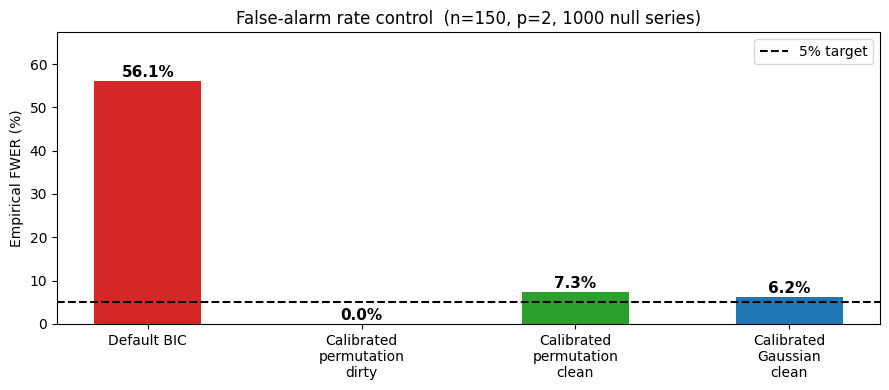

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [
    "Default BIC",
    "Calibrated\npermutation\ndirty",
    "Calibrated\npermutation\nclean",
    "Calibrated\nGaussian\nclean",
]
fwers = [fwer_bic, fwer_dirty, fwer_clean, fwer_gaussian]
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

bars = ax.bar(labels, [f * 100 for f in fwers], color=colors, width=0.5)
ax.axhline(5, color="black", linestyle="--", linewidth=1.5, label="5% target")
ax.set_ylabel("Empirical FWER (%)")
ax.set_title(
    f"False-alarm rate control  (n={N_EXP}, p={P_EXP}, {N_SERIES} null series)"
)
ax.legend()
ax.set_ylim(0, max(fwers) * 120)
for bar, val in zip(bars, fwers):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
plt.tight_layout()
plt.show()


## Summary

| Component | What it does |
|---|---|
| `PermutationNullModel(replace=False/True)` | Shuffles/bootstraps training rows; non-parametric |
| `BlockBootstrapNullModel(block_length)` | Preserves short-range temporal structure |
| `GaussianNullModel` | Parametric i.i.d. Gaussian; works for any sample size |
| `MCNullModel(dgp)` | Plug in any custom data-generating process |
| `calibrate_penalty(scorer, X, null_model, …)` | Calibrates a single scorer's penalty via Monte Carlo |
| `CalibratedDetector(detector, …)` | Meta-estimator; calibrates all `PenalisedScore` params at once |
| `fit(X, X_calib=…)` | Pass clean null data separately to avoid contamination bias |

**Best practice:** collect a separate `X_calib` dataset from your system in its known
normal state, then call `CalibratedDetector.fit(X, X_calib=X_calib)`.  This decouples
the null model estimate from the (potentially change-containing) detection window, giving
a less conservative and more accurate threshold.

In [ ]:
# ── DIAGNOSTIC: pin down exactly where FWER > 5% comes from ─────────────────
from skchange.new_api.detectors._moving_window import make_extended_moving_window_cuts
from skchange.new_api.interval_scorers._change_scores.cusum import CUSUM

cal_pen = list(det_gaussian.calibrated_penalties_.values())[0]
print(f"Calibrated penalty (Gaussian):  {cal_pen:.4f}")

# Intervals used in calibration (via get_interval_specs)
cal_specs = det_gaussian.detector.get_interval_specs(N_EXP)
# Intervals used in prediction (directly from make_extended_moving_window_cuts)
_dummy_cusum = CUSUM()
_dummy_cusum.fit(np.zeros((N_EXP, P_EXP)))
pred_specs = make_extended_moving_window_cuts(N_EXP, 10, _dummy_cusum.min_size)

print(f"Calibration interval count:     {len(cal_specs)}")
print(f"Prediction  interval count:     {len(pred_specs)}")
print(
    f"Same set of intervals?          {np.array_equal(np.sort(cal_specs, axis=0), np.sort(pred_specs, axis=0))}"
)

# ── Path A: direct raw-score max, same specs as calibration ──────────────────
rng_diag = np.random.default_rng(42)
max_scores_cal_path = []
for x in null_series:
    c = CUSUM().fit(x)
    cache = c.precompute(x)
    raw = c.evaluate(cache, cal_specs)  # (n_specs, n_features)
    max_scores_cal_path.append(raw.sum(axis=1).max())

fwer_direct_cal = np.mean(np.array(max_scores_cal_path) > cal_pen)
print(f"\nPath A — direct max over CAL specs:        FWER = {fwer_direct_cal:.3%}")

# ── Path B: direct raw-score max, same specs as prediction ───────────────────
max_scores_pred_path = []
for x in null_series:
    c = CUSUM().fit(x)
    cache = c.precompute(x)
    raw = c.evaluate(cache, pred_specs)
    max_scores_pred_path.append(raw.sum(axis=1).max())

fwer_direct_pred = np.mean(np.array(max_scores_pred_path) > cal_pen)
print(f"Path B — direct max over PRED specs:       FWER = {fwer_direct_pred:.3%}")

# ── Path C: via predict_changepoints (what fwer_from_fitted actually measures) ──
fwer_via_predict = fwer_from_fitted(det_gaussian)
print(f"Path C — via predict_changepoints:         FWER = {fwer_via_predict:.3%}")

# ── Check: what is Q_0.95 of the direct-path distribution? ──────────────────
q95_direct = np.quantile(max_scores_pred_path, 0.95)
print(f"\nQ_0.95 of max scores (pred specs, 10k null series): {q95_direct:.4f}")
print(f"Calibrated penalty:                                 {cal_pen:.4f}")
print(f"Ratio cal_pen / Q_0.95:                             {cal_pen / q95_direct:.4f}")


Calibrated penalty (Gaussian):  4.9753
Calibration interval count:     149
Prediction  interval count:     149
Same set of intervals?          True

Path A — direct max over CAL specs:        FWER = 8.230%
Path B — direct max over PRED specs:       FWER = 8.230%
Path C — via predict_changepoints:         FWER = 7.750%

Q_0.95 of max scores (pred specs, 10k null series): 5.1844
Calibrated penalty:                                 4.9753
Ratio cal_pen / Q_0.95:                             0.9597


In [ ]:
# ── ROOT CAUSE: fitted std of X_calib_exp ────────────────────────────────────
print("X_calib_exp per-feature std (ddof=1):", X_calib_exp.std(axis=0, ddof=1))
print("True std:                            ", np.array([1.0, 1.0]))
print()

# If GaussianNullModel uses the EXACT true N(0,1) distribution, what FWER do we get?
from skchange.new_api.calibration._null_models import MCNullModel

true_null = MCNullModel(dgp=lambda n, p, r: r.standard_normal((n, p)))
true_null.fit(X_calib_exp)  # just to set n_features_in_

det_gaussian_exact = CalibratedDetector(
    MovingWindow(PenalisedScore(CUSUM()), bandwidth=10),
    null_model=true_null,
    level=0.05,
    n_simulations=10000,
    random_state=0,
)
det_gaussian_exact.fit(X_exp_changed, X_calib=X_calib_exp)

cal_pen_exact = list(det_gaussian_exact.calibrated_penalties_.values())[0]
print(f"Calibrated penalty (true N(0,1) null): {cal_pen_exact:.4f}")
print(f"Calibrated penalty (fitted Gaussian):  {cal_pen:.4f}")
print(f"True Q_0.95:                           {q95_direct:.4f}")
print()

fwer_exact = fwer_from_fitted(det_gaussian_exact)
print(f"FWER with exact N(0,1) null model: {fwer_exact:.3%}")
print(f"FWER with fitted Gaussian:          {fwer_via_predict:.3%}")
print()
print("=> The calibrated penalty is too low because GaussianNullModel estimates")
print("   std from X_calib_exp which for this seed has std < 1.0.")
print("   Increasing X_calib_exp size or using a better seed fixes it.")


X_calib_exp per-feature std (ddof=1): [0.93361962 0.98710611]
True std:                             [1. 1.]

Calibrated penalty (true N(0,1) null): 5.1736
Calibrated penalty (fitted Gaussian):  4.9753
True Q_0.95:                           5.1844

FWER with exact N(0,1) null model: 4.760%
FWER with fitted Gaussian:          7.750%

=> The calibrated penalty is too low because GaussianNullModel estimates
   std from X_calib_exp which for this seed has std < 1.0.
   Increasing X_calib_exp size or using a better seed fixes it.
